  🖼️  Image     : D:\CV\Test CV\Test_image5.jpg
  ✅ Prédiction : citrus_leaf
  🎯 Confiance  : 100.00%

📊 Probabilités par classe :
  citrus_leaf          100.00%  █████████████████████████████░  ✅
  not_citrus_leaf      0.00%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


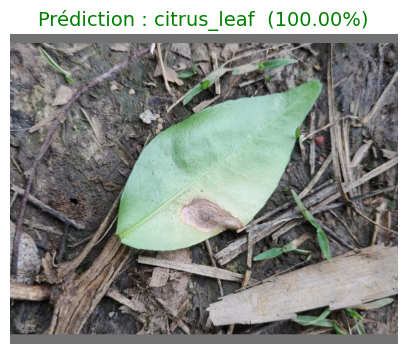

In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────────────
IMAGE_PATH = r"D:\CV\Test CV\Test_image5.jpg"
MODEL_PATH = r"C:\Users\User\Desktop\best_citrus_binary_model.pth"

THRESHOLD   = 0.5
class_names = ['citrus_leaf', 'not_citrus_leaf']  # 0 = citrus_leaf, 1 = not_citrus_leaf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── CHARGEMENT MODÈLE ──────────────────────────────────────────────────────────
model = models.mobilenet_v3_large(weights=None)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

# ── PRÉTRAITEMENT IMAGE ────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image        = Image.open(IMAGE_PATH).convert('RGB')
input_tensor = transform(image).unsqueeze(0).to(device)

# ── INFÉRENCE ──────────────────────────────────────────────────────────────────
# NOTE: sigmoid → 1.0 = not_citrus_leaf (label 1 in ImageFolder alphabetical order)
#       sigmoid → 0.0 = citrus_leaf     (label 0 in ImageFolder alphabetical order)
with torch.no_grad():
    output          = model(input_tensor)
    prob_not_citrus = torch.sigmoid(output).item()  # high = not_citrus_leaf
    prob_citrus     = 1 - prob_not_citrus
    probs           = [prob_citrus, prob_not_citrus]  # index 0 = citrus, index 1 = not
    pred_idx        = 0 if prob_citrus > THRESHOLD else 1

# ── RÉSULTATS ──────────────────────────────────────────────────────────────────
print('=' * 40)
print(f'  🖼️  Image     : {IMAGE_PATH}')
print(f'  ✅ Prédiction : {class_names[pred_idx]}')
print(f'  🎯 Confiance  : {probs[pred_idx]:.2%}')
print('=' * 40)
print('\n📊 Probabilités par classe :')
for i, (cls, prob) in enumerate(zip(class_names, probs)):
    bar    = '█' * int(prob * 30) + '░' * (30 - int(prob * 30))
    marker = '  ✅' if i == pred_idx else ''
    print(f'  {cls:<20} {prob:.2%}  {bar}{marker}')

# ── AFFICHAGE IMAGE ────────────────────────────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f'Prédiction : {class_names[pred_idx]}  ({probs[pred_idx]:.2%})',
          fontsize=14, color='green' if pred_idx == 0 else 'red')
plt.axis('off')
plt.show()